## Loading

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import os
from data_cleaning_class import DataCleaner
import math
from pca import PCA_Python
import plotly.graph_objects as go



pd.set_option('display.max_rows', None)

script_dir = os.getcwd()
csv_path = os.path.join(script_dir , "kl.csv")
print(csv_path)

decoded_df = pd.read_csv(csv_path , encoding="cp1252")

/home/youssef/mia_ai/Task_2/Task2.3/kl.csv


## Cleaning

In [2]:
decoded_df = decoded_df[["Name","Finishing" , "ShortPassing" , "Dribbling" , "SprintSpeed" , "Strength" , "Stamina" , "Interceptions" , "StandingTackle" ,"Value"]]
print(decoded_df[decoded_df["Name"].str.contains("salah", case=False, na=False)])
def parse_currency(val):
    val = str(val).replace('€', '').strip()
    multiplier = 1
    
    if val.endswith('M'):
        multiplier = 1_000_000
        val = val[:-1]
    elif val.endswith('K'):
        multiplier = 1_000
        val = val[:-1]
    try:
        return float(val) * multiplier
    except ValueError:
        return np.nan


decoded_df["Value"] = decoded_df["Value"].apply(parse_currency)

print(decoded_df[decoded_df["Name"].str.contains("salah", case=False, na=False)])
decoded_df = DataCleaner(decoded_df).clean_df()
print("Here3")
decoded_df[decoded_df["name"].str.contains("salah", case=False, na=False)]
print(decoded_df[decoded_df["name"].str.contains("salah", case=False, na=False)])



        Name  Finishing  ShortPassing  Dribbling  SprintSpeed  Strength  \
26  M. Salah       90.0          82.0       89.0         91.0      70.0   

    Stamina  Interceptions  StandingTackle     Value  
26     84.0           55.0            43.0  ï¿½69.5M  
        Name  Finishing  ShortPassing  Dribbling  SprintSpeed  Strength  \
26  M. Salah       90.0          82.0       89.0         91.0      70.0   

    Stamina  Interceptions  StandingTackle  Value  
26     84.0           55.0            43.0    NaN  
the  cleaning methods worked
Here3
        name  finishing  shortpassing  dribbling  sprintspeed  strength  \
26  M. Salah       90.0          82.0       89.0         91.0      70.0   

    stamina  interceptions  standingtackle  
26     84.0           55.0            43.0  


## Data standardizing -we'll ignore that block to try without normalization 
i except that it'll think that those of higher values - features with higher floor limits will domain because they'll seem "dominate" 

In [3]:
decoded_df_standardized = decoded_df.copy()
names = decoded_df_standardized["name"]
feature_cols = decoded_df_standardized.columns.drop("name")
decoded_df_standardized[feature_cols] = (
    decoded_df_standardized[feature_cols] - decoded_df_standardized[feature_cols].mean()
) / decoded_df_standardized[feature_cols].std()

## Similarity matrices


### Similarity metrics 

In [4]:
class SimilarityMetrics():
    def __init__(self , A , B , axis :int = 1):
            self.A = np.array(A) 
            self.B = np.array(B)
            self.axis = axis

    #dot product is a measurement of how two vectors are aligned,in this metric as dot product increases similiarity does
    #and its cos theta between them anyway using simple LA
    def cosine_similarity(self): 
            dot = np.sum(self.A * self.B, axis=self.axis)
            cos_sim = dot / (
                np.linalg.norm(self.A, axis=self.axis) *
                np.linalg.norm(self.B, axis=self.axis)
            )
            return cos_sim
    

    # the shortest path(l2) between two vectors , can be large even if they're with the same angle but difference altitudes
    def euclidean_distance(self):
            return np.linalg.norm(self.A - self.B, axis=self.axis)

    # measures path length using the sum of absolute differences , less sensitive to large outliers because error isn't squared
    def manhattan_distance(self):
            return np.sum(np.abs(self.B - self.A), axis=self.axis)

    # measures the linear relationship between two variables rather than relying on the distance
    # it's suitable if two vectors share the same shape but of difference magnitudes(think that'll make it behave better than the above two for non-normalized data)
    def pearson_correlation(self):
        std_A = self.A - self.A.mean(axis=self.axis, keepdims=True)
        std_B = self.B - self.B.mean(axis=self.axis, keepdims=True)

        num = np.sum(std_A * std_B, axis=self.axis)
        denom = (
            np.sqrt(np.sum(std_A**2, axis=self.axis)) *
            np.sqrt(np.sum(std_B**2, axis=self.axis))
        )

        return num / denom

    #measures the largest diff along one of the axis,useful in things like path_finding on grids -used similar thing for robocon
    #it also makes diagonal moves have the same cost since it's just another axis of movement
    def chebyshev_distance(self):
        return np.max(np.abs(self.A - self.B), axis=self.axis)

## Top 5

In [5]:
def get_top_similar(df: pd.DataFrame , n =  5, target : str = "M. Salah"):
    # smaller value(distance) = more similar for these; higher value (similarity) = more similar for these two
    ascending_map = {
        "cosine_similarity": False,
        "pearson_correlation": False,
        "euclidean_distance": True,
        "manhattan_distance": True,
        "chebyshev_distance": True,
    }
    feature_cols = df.columns.drop("name")
    mask = df["name"].str.lower() == target.lower()
    target_vec = df.loc[mask, feature_cols].values.flatten()


    # exclude the target himself
    others = df[df["name"] != target].reset_index(drop=True)
    A = others[feature_cols].values
    B = np.tile(target_vec, (A.shape[0], 1))

    similarity = SimilarityMetrics(A, B) 
    results = {}
    for metric_name, ascending in ascending_map.items():
        scores = getattr(similarity, metric_name)()
        temp = others[["name"]].copy()
        temp[metric_name] = scores
        temp = temp.sort_values(metric_name, ascending=ascending).head(n)
        results[metric_name] = temp.reset_index(drop=True)

    return results

def plot_top_similar(top5, target="M. Salah"):
    n_metrics = len(top5)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    base_color = "#4C72B0"
    dark_color = "#2C4A78"

    for i, (metric, table) in enumerate(top5.items()):
        ax = axes[i]

        table = table.reset_index()

        preferred = [c for c in table.columns if c.lower() in ("name", "player")]
        name_col = preferred[0] if preferred else next(
            c for c in table.columns if c.lower() == "index"
        )

        if metric in table.columns:
                    score_col = metric
        else:
                    score_col = next(
                        c for c in table.columns
                        if c != name_col and c.lower() != "index" and pd.api.types.is_numeric_dtype(table[c])
                    )

        # similarity: higher = better -> ascending sort puts the best last -> plotted at TOP
        # distance:  lower  = better -> descending sort puts the best last -> plotted at TOP
        ascending = "distance" not in metric.lower()
        table = table.sort_values(score_col, ascending=ascending)
        table = table.iloc[::-1] if False else table  # (kept for clarity, no-op)

        # for barh, first row plots at the bottom -- we want the best match at the TOP
        table = table.sort_values(score_col, ascending=ascending)

        values = table[score_col].to_numpy(dtype=float)
        lo, hi = values.min(), values.max()
        span = hi - lo
        pad = span * 0.15 if span > 0 else abs(hi) * 0.05 or 1.0
        baseline = lo - pad  # suitable lower limit instead of 0, so differences are visible

        y_pos = range(len(table))
        colors = [dark_color if j == len(table) - 1 else base_color for j in range(len(table))]

        bars = ax.barh(y_pos, values - baseline, left=baseline, color=colors, height=0.6)
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(table[name_col].astype(str))
        ax.set_xlim(baseline, hi + pad)

        for bar, val in zip(bars, values):
            ax.annotate(f"{val:.3f}", (bar.get_x() + bar.get_width(), bar.get_y() + bar.get_height() / 2),
                        va="center", ha="left", fontsize=8, xytext=(4, 0),
                        textcoords="offset points", color="#1B3A57")

        ax.set_title(f"Top 10 by {metric}", fontsize=12, weight="bold")
        sns.despine(ax=ax, left=True, bottom=True)
        ax.grid(axis="x", alpha=0.3)

    for j in range(n_metrics, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Most Similar Players to {target}", fontsize=15, weight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Standardized Data

### M.salah


Top 10 by cosine_similarity:
            name  cosine_similarity
0          Jason           0.990336
1      J. Murphy           0.987575
2        I. Sosa           0.986407
3  J. Absalonsen           0.982455
4      M. Britos           0.979721
5        R. Skov           0.978244
6   A. Lacazette           0.978070
7    Fernandinho           0.977758
8    M. Svanberg           0.977322
9       K. Roofe           0.976938

Top 10 by pearson_correlation:
            name  pearson_correlation
0     S. Bertram             0.990464
1          Jason             0.988942
2      T. Werner             0.987893
3   J. Cristaldo             0.987617
4     Kike Barja             0.987321
5  J. Bertilsson             0.985140
6    M. Niemeyer             0.983288
7    B. Woodburn             0.983236
8       M. Rojas             0.982900
9    G. Williams             0.981465

Top 10 by euclidean_distance:
            name  euclidean_distance
0   A. Lacazette            0.924524
1        M. Reus   

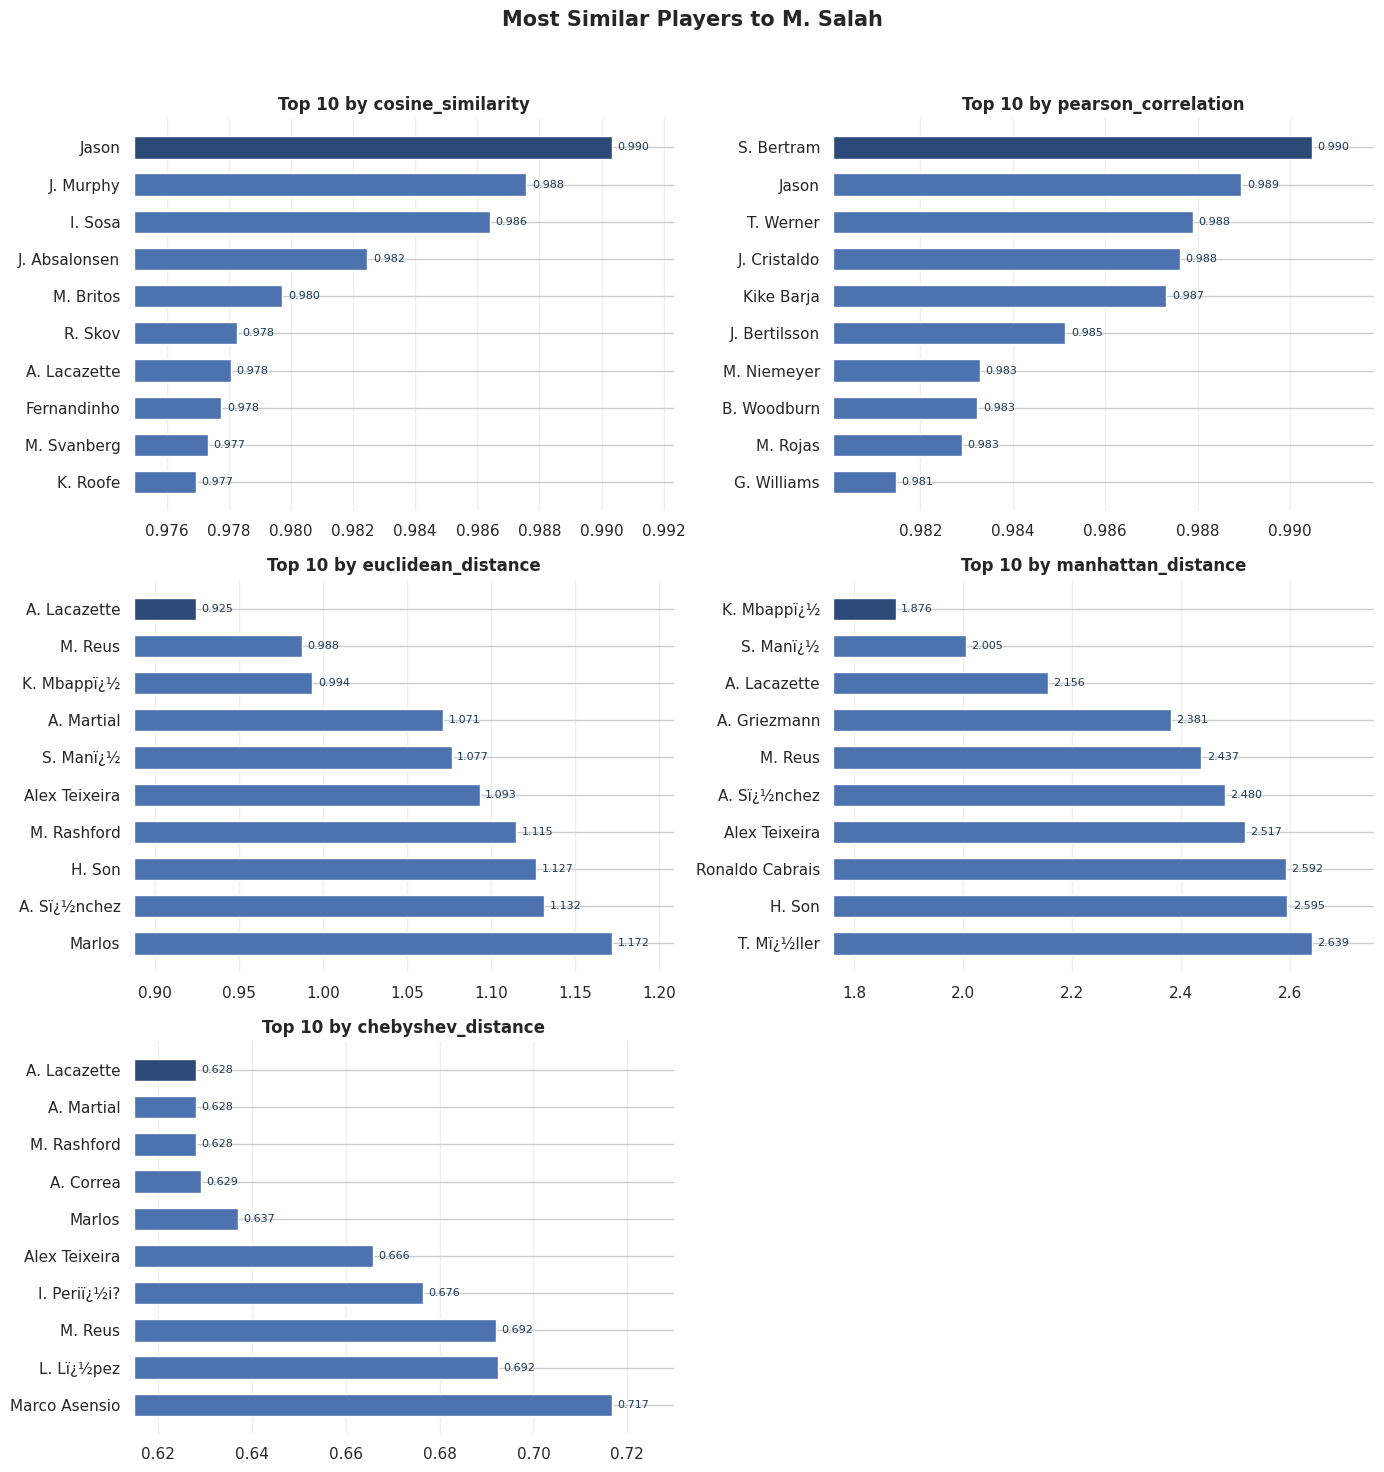

In [6]:
top10_salah = get_top_similar(df = decoded_df_standardized, n=10, target="M. Salah")
for metric, table in top10_salah.items():
    print(f"\nTop {10} by {metric}:") 
    print(table)

plot_top_similar(top10_salah, target="M. Salah")

### trying a goalkeeper 




Top 10 by cosine_similarity:
             name  cosine_similarity
0  J. Rodrï¿½guez           0.958688
1         W. Hahn           0.952256
2         R. Riou           0.950751
3     N. Guzmï¿½n           0.950737
4      J. Butland           0.948921
5        M. Fraga           0.946217
6         Ederson           0.945359
7     D. Bouzanis           0.944781
8     A. Kwarasey           0.940503
9        C. Bravo           0.940113

Top 10 by pearson_correlation:
             name  pearson_correlation
0      M. Lansing             0.957644
1     D. Bouzanis             0.944637
2         W. Hahn             0.944275
3  J. Rodrï¿½guez             0.941551
4     A. Kwarasey             0.938311
5        C. Bravo             0.937339
6     Josï¿½ Juan             0.936407
7         D. Roef             0.934321
8         B. Leno             0.932499
9     N. Guzmï¿½n             0.928201

Top 10 by euclidean_distance:
          name  euclidean_distance
0      Ederson            1.107666
1

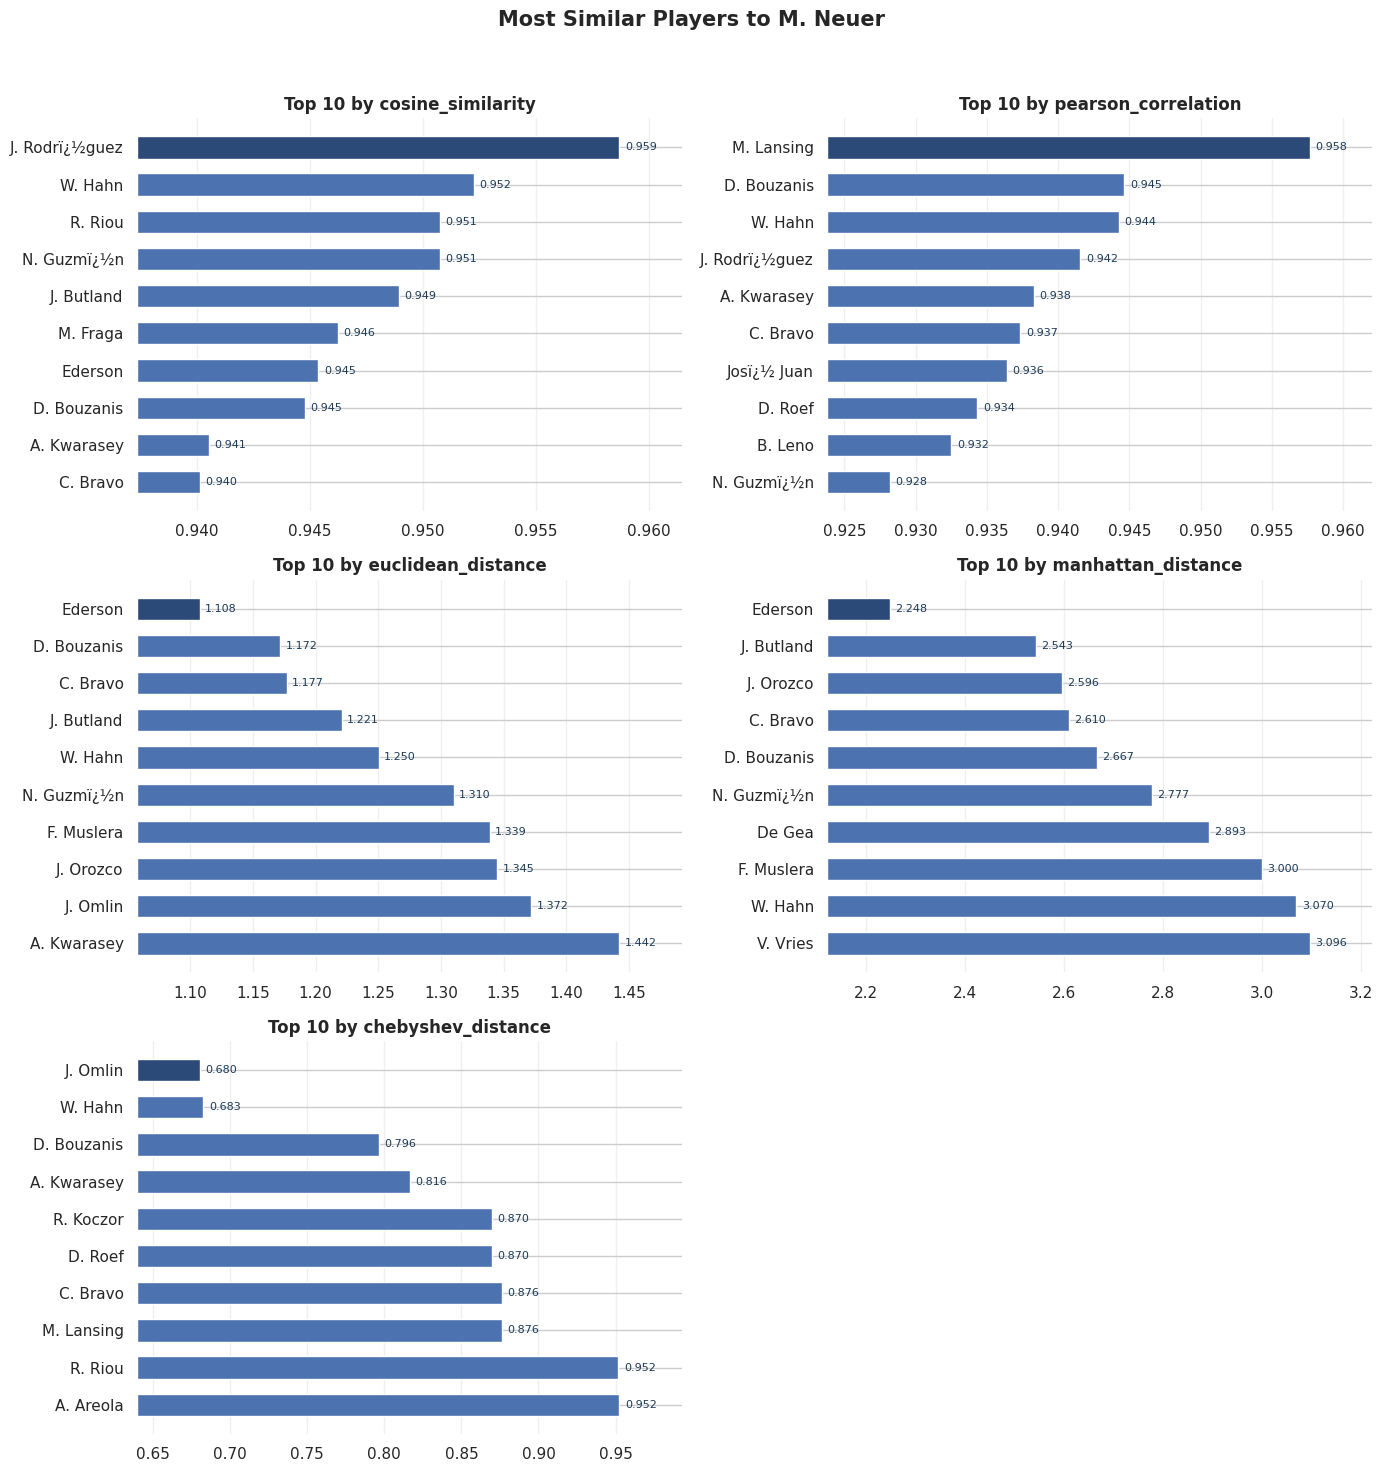

In [7]:
top10_neuer = get_top_similar(df = decoded_df_standardized, n=10, target="M. Neuer")
for metric, table in top10_neuer.items():
    print(f"\nTop {10} by {metric}:")
    print(table)

plot_top_similar(top10_neuer, target="M. Neuer")

## Not Standardized

In [8]:
top10_non_standard = get_top_similar(df = decoded_df, n=10, target="M. Salah")
for metric, table in top10_non_standard.items():
    print(f"\nTop {10} by {metric}:")
    print(table)


Top 10 by cosine_similarity:
                 name  cosine_similarity
0           M. Gradel           0.999284
1         T. Minamino           0.999086
2               Jason           0.999005
3         M. Niemeyer           0.998907
4  Davide Eustï¿½quio           0.998818
5             H. Bunn           0.998765
6          J. Gï¿½mez           0.998755
7  ï¿½lvaro Jimï¿½nez           0.998685
8          A. El Said           0.998647
9      Diego Tardelli           0.998633

Top 10 by pearson_correlation:
           name  pearson_correlation
0     T. Werner             0.996010
1      Hï¿½ctor             0.993556
2  A. Bï¿½yï¿½k             0.989022
3     B. Kavlak             0.988361
4        H. Son             0.987592
5    F. Honorat             0.987547
6  J. Sambenito             0.987273
7     Q. Promes             0.986270
8   S. Beusnard             0.986102
9  K. Angielski             0.985899

Top 10 by euclidean_distance:
            name  euclidean_distance
0        M. 

## Using PCA

In [9]:
def get_shortlist_names(results: dict, unique: bool = True) :
    if not unique:
        return {metric: table["name"].tolist() for metric, table in results.items()}

    all_names = []
    for table in results.values():
        all_names.extend(table["name"].tolist())

    # preserve order, drop duplicates
    seen = set()
    ordered_unique = []
    for name in all_names:
        if name not in seen:
            seen.add(name)
            ordered_unique.append(name)

    return ordered_unique

def PCA_similarity(df : pd.DataFrame , target = "M. Salah" , n:int =2):
    feature_cols = df.columns.drop("name")
    df = df.dropna(subset=feature_cols)  #removing all nulls (goal keepers) since that broken eigen value -not converging

    X = df[feature_cols].values.tolist()

    pca = PCA_Python(X , n)
    projected , explained_variance = pca.get_PCA()
    print (f"PCA explained {explained_variance*100}% of the variance")

    pc_cols = [f"PC{i+1}" for i in range(n)]
    pca_df = pd.DataFrame(projected, columns=pc_cols)
    pca_df["name"] = df["name"].values #PCAn then names

    top10 =get_top_similar(df=decoded_df_standardized, n=5, target=target)
    shortlist_names = get_shortlist_names(top10)


    # visual 
    if n == 2 :
        ig, ax = plt.subplots(figsize=(10, 8))

        # all players in grey
        ax.scatter(pca_df["PC1"], pca_df["PC2"], c="lightgrey", s=15, alpha=0.5, label="All players")

        # shortlist highlighted
        shortlist_pts = pca_df[pca_df["name"].isin(shortlist_names)]
        ax.scatter(shortlist_pts["PC1"], shortlist_pts["PC2"], c="seagreen", s=80,
                edgecolors="black", label="Shortlist", zorder=3)

        # target highlighted separately, bigger/different color
        target_pt = pca_df[pca_df["name"] == target]
        ax.scatter(target_pt["PC1"], target_pt["PC2"], c="crimson", s=200, marker="*",
                edgecolors="black", label=target, zorder=4)

        # label the shortlist + target points
        for _, row in pd.concat([shortlist_pts, target_pt]).iterrows():
            ax.annotate(row["name"], (row["PC1"], row["PC2"]),
                        textcoords="offset points", xytext=(6, 6), fontsize=9)

        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_title(f"Player Pool in PCA Space — {target} and Shortlist Highlighted")
        ax.legend()
        plt.tight_layout()
        plt.show()

    elif n == 3:
        shortlist_pts = pca_df[pca_df["name"].isin(shortlist_names)]
        target_pt = pca_df[pca_df["name"] == target]

        fig = go.Figure()

        # all players (grey, small, low opacity)
        fig.add_trace(go.Scatter3d(
            x=pca_df["PC1"], y=pca_df["PC2"], z=pca_df["PC3"],
            mode="markers",
            marker=dict(size=3, color="lightgrey", opacity=0.4),
            name="All players",
            text=pca_df["name"],
            hovertemplate="%{text}<extra></extra>"
        ))

        # shortlist (seagreen, labeled)
        fig.add_trace(go.Scatter3d(
            x=shortlist_pts["PC1"], y=shortlist_pts["PC2"], z=shortlist_pts["PC3"],
            mode="markers+text",
            marker=dict(size=6, color="seagreen", line=dict(color="black", width=1)),
            text=shortlist_pts["name"],
            textposition="top center",
            textfont=dict(size=9),
            name="Shortlist",
            hovertemplate="%{text}<extra></extra>"
        ))

        # target (crimson diamond, labeled)
        fig.add_trace(go.Scatter3d(
            x=target_pt["PC1"], y=target_pt["PC2"], z=target_pt["PC3"],
            mode="markers+text",
            marker=dict(size=10, color="crimson", symbol="diamond",
                        line=dict(color="black", width=1)),
            text=target_pt["name"],
            textposition="top center",
            textfont=dict(size=10, color="crimson"),
            name=target,
            hovertemplate="%{text}<extra></extra>"
        ))

        fig.update_layout(
            title=f"Player Pool in PCA Space (3D) — {target} and Shortlist Highlighted",
            scene=dict(
                xaxis_title="PC1",
                yaxis_title="PC2",
                zaxis_title="PC3",
            ),
            legend=dict(itemsizing="constant"),
            width=900,
            height=750,
            margin=dict(l=0, r=0, b=0, t=50),
        )

        fig.show()
        # fig.write_html("pca_3d_interactive.html")  # uncomment to save as standalone HTML

PCA explained 77.63109005001718% of the variance


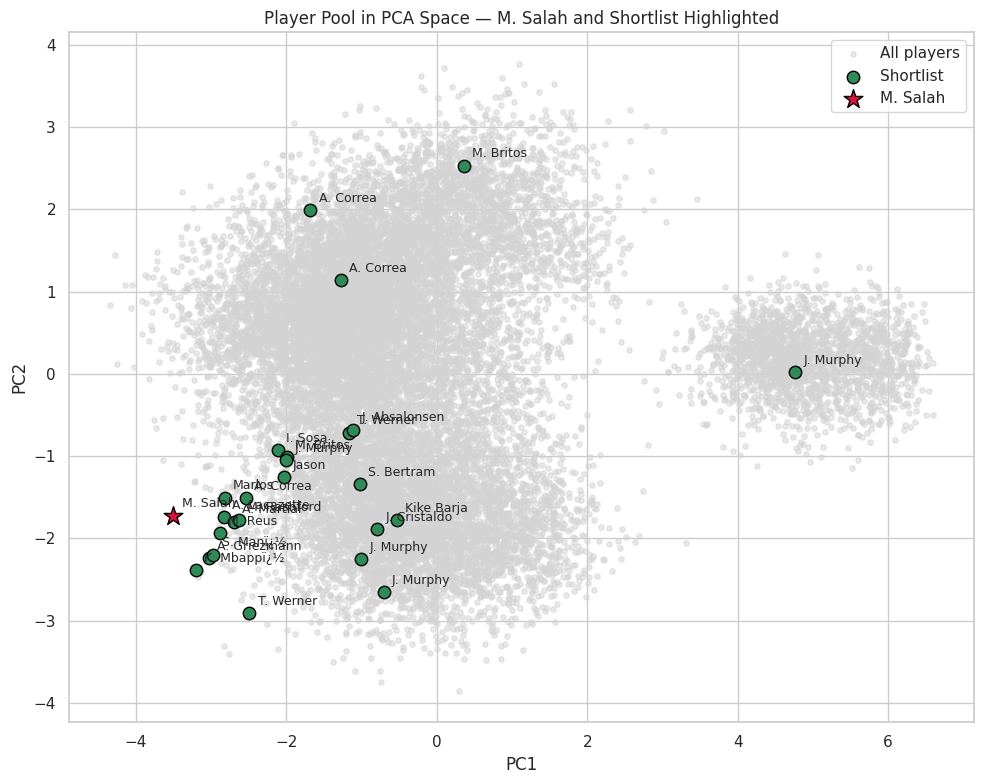

PCA explained 87.84101684673355% of the variance


PCA explained 87.84101684673355% of the variance


In [10]:
PCA_similarity(df=decoded_df, n = 2) #70% variance is explained
PCA_similarity(df=decoded_df, n = 3)

PCA_similarity(df=decoded_df, n = 3 , target = "M. Neuer")
#this j rodriguez is very off